# Exact diagonalization of the pairing + particle–hole toy model

This notebook solves, by **exact diagonalization**, the schematic two-body Hamiltonian
introduced in

> M. Hjorth-Jensen, D. J. Dean, G. Hagen and S. Kvaal,
> *Many-body interactions and nuclear structure*,
> J. Phys. G: Nucl. Part. Phys. **37**, 064035 (2010), Sec. 2.1.

The model has $L$ **doubly degenerate**, equally spaced single-particle levels
$p = 1, 2, \dots, L$, each carrying a spin label $\sigma = \pm$, populated by
$N$ spin-$\tfrac12$ fermions. The Hamiltonian is $\hat H = \hat H_0 + \hat V$ with

$$
\hat H_0 = \xi \sum_{p\sigma}(p-1)\, a^\dagger_{p\sigma} a_{p\sigma},
$$

$$
\hat V \;=\; -\tfrac12\, g \sum_{pq} a^\dagger_{p+}a^\dagger_{p-}a_{q-}a_{q+}
\;-\; \tfrac12\, f \sum_{pqr}\Big(a^\dagger_{p+}a^\dagger_{p-}a_{q-}a_{r+} + \text{h.c.}\Big).
$$

* $\hat H_0$ gives each level $p$ the single-particle energy $\xi(p-1)$; we set $\xi=1$.
* The **pairing** term (strength $g$) scatters a *pair* — both spin components of one level —
  from level $q$ to level $p$.
* The **particle–hole** term (strength $f$) removes a spin-down from level $q$ and a spin-up
  from level $r$ and deposits a pair at level $p$ (plus the Hermitian conjugate). It can
  therefore *break* pairs.

Both terms conserve $N_+$ and $N_-$ separately, so $S_z=(N_+-N_-)/2$ is a good quantum number.
The low-lying spectrum lives in the balanced sector ($S_z=0$ for even $N$), which is the default below.

The code is written to be **flexible in $N$ and $L$**, uses a bitstring (occupation-number)
representation with proper fermion signs, and extracts the few lowest eigenvalues with the
**Lanczos** algorithm (`scipy.sparse.linalg.eigsh`, an implicitly restarted Lanczos solver).


In [1]:
import numpy as np
from itertools import combinations
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import eigsh

import matplotlib.pyplot as plt
%matplotlib inline

UP, DN = +1, -1   # spin labels

## 1. Single-particle indexing and the many-body basis

We order the $2L$ spin-orbitals so that orbital index
$o = 2(p-1) + \begin{cases}0 & \sigma=+\\ 1 & \sigma=-\end{cases}$,
i.e. level $p = o//2 + 1$. A Slater determinant is an integer whose bit $o$ is set when that
spin-orbital is occupied. The many-body basis is every bitstring with exactly $N$ bits set;
optionally we keep only a fixed $2S_z = N_+ - N_-$ sector (`sz2`).

In [2]:
def orbital_index(level, spin):
    """Map (level p = 1..L, spin +/-) to a linear spin-orbital index 0..2L-1."""
    return 2 * (level - 1) + (0 if spin == UP else 1)

def level_of(o):
    return o // 2 + 1

def build_basis(n_levels, n_part, sz2=None):
    """All occupation bitstrings with n_part fermions in 2*n_levels spin-orbitals.
    If sz2 is not None, keep only states with N_up - N_down == sz2."""
    norb = 2 * n_levels
    basis = []
    for occ in combinations(range(norb), n_part):
        if sz2 is not None:
            nup = sum(1 for o in occ if o % 2 == 0)
            if (nup - (n_part - nup)) != sz2:
                continue
        state = 0
        for o in occ:
            state |= (1 << o)
        basis.append(state)
    index = {s: i for i, s in enumerate(basis)}
    return basis, index

## 2. Creation / annihilation operators with fermion signs

Anticommutation is enforced by a Jordan–Wigner phase: acting on spin-orbital $o$ picks up
$(-1)^{\#\text{occupied orbitals below }o}$. A generic two-body operator
$a^\dagger_i a^\dagger_j a_k a_l$ is applied right-to-left, and returns the resulting
determinant together with its accumulated sign (or `None` if the state is annihilated).

In [3]:
def _count_below(state, o):
    return bin(state & ((1 << o) - 1)).count("1")

def annihilate(state, o):
    if not (state >> o) & 1:
        return None, 0
    sign = -1 if (_count_below(state, o) & 1) else 1
    return state & ~(1 << o), sign

def create(state, o):
    if (state >> o) & 1:
        return None, 0
    sign = -1 if (_count_below(state, o) & 1) else 1
    return state | (1 << o), sign

def apply_2body(state, i, j, k, l):
    """Apply a^dag_i a^dag_j a_k a_l to a determinant. Returns (new_state, sign)."""
    s, sgn = annihilate(state, l)
    if s is None: return None, 0
    s, g = annihilate(s, k)
    if s is None: return None, 0
    sgn *= g
    s, g = create(s, j)
    if s is None: return None, 0
    sgn *= g
    s, g = create(s, i)
    if s is None: return None, 0
    sgn *= g
    return s, sgn

## 3. Building the Hamiltonian matrix

For every basis determinant we add the diagonal $\hat H_0$ contribution, then loop over the
level indices of the pairing term ($p,q$) and the particle–hole term ($p,q,r$ and its
Hermitian conjugate), routing each generated determinant back to its basis index. The result
is a sparse, real, symmetric matrix.

In [4]:
def build_hamiltonian(n_levels, n_part, g, f, xi=1.0, sz2=None):
    basis, index = build_basis(n_levels, n_part, sz2)
    dim = len(basis)
    H = lil_matrix((dim, dim))
    for a, state in enumerate(basis):
        # --- one-body H0: energy xi*(p-1) per occupied spin-orbital ---
        e = 0.0
        for o in range(2 * n_levels):
            if (state >> o) & 1:
                e += xi * (level_of(o) - 1)
        H[a, a] += e

        # --- pairing: -g/2 sum_{p,q} adag_{p+} adag_{p-} a_{q-} a_{q+} ---
        for pL in range(1, n_levels + 1):
            i = orbital_index(pL, UP); j = orbital_index(pL, DN)
            for qL in range(1, n_levels + 1):
                k = orbital_index(qL, DN); l = orbital_index(qL, UP)
                s, sgn = apply_2body(state, i, j, k, l)
                if s is not None and s in index:
                    H[index[s], a] += -0.5 * g * sgn

        # --- particle-hole: -f/2 sum_{p,q,r} adag_{p+} adag_{p-} a_{q-} a_{r+} ---
        for pL in range(1, n_levels + 1):
            i = orbital_index(pL, UP); j = orbital_index(pL, DN)
            for qL in range(1, n_levels + 1):
                k = orbital_index(qL, DN)
                for rL in range(1, n_levels + 1):
                    l = orbital_index(rL, UP)
                    s, sgn = apply_2body(state, i, j, k, l)
                    if s is not None and s in index:
                        H[index[s], a] += -0.5 * f * sgn

        # --- Hermitian conjugate of the p-h term:
        #     -f/2 sum_{p,q,r} adag_{r+} adag_{q-} a_{p-} a_{p+} ---
        for pL in range(1, n_levels + 1):
            k2 = orbital_index(pL, DN); l2 = orbital_index(pL, UP)
            for qL in range(1, n_levels + 1):
                j2 = orbital_index(qL, DN)
                for rL in range(1, n_levels + 1):
                    i2 = orbital_index(rL, UP)
                    s, sgn = apply_2body(state, i2, j2, k2, l2)
                    if s is not None and s in index:
                        H[index[s], a] += -0.5 * f * sgn
    return csr_matrix(H), basis, index

## 4. Lanczos solver for the lowest eigenvalues

`scipy.sparse.linalg.eigsh` with `which='SA'` is an implicitly restarted Lanczos algorithm
and returns the few *smallest algebraic* eigenvalues without forming the dense matrix — exactly
what we want when only a handful of low-lying states matter. For very small matrices (where
$k \ge \dim-1$) we fall back to a dense solve.

In [5]:
def lowest_eigenvalues(n_levels, n_part, g, f, k=6, xi=1.0, sz2=0):
    """Few lowest eigenvalues via Lanczos. sz2=0 -> balanced (S_z=0) sector by default;
    pass sz2=None to diagonalize the full N-particle space."""
    H, basis, index = build_hamiltonian(n_levels, n_part, g, f, xi, sz2)
    dim = H.shape[0]
    if k >= dim - 1:                       # tiny block: dense is safer
        return np.sort(np.linalg.eigvalsh(H.toarray()))[:k]
    return np.sort(eigsh(H, k=k, which='SA', return_eigenvectors=False))

## 5. Sanity checks

Three independent checks that the construction is correct:

1. **Hermiticity** — the matrix must equal its transpose.
2. **Non-interacting limit** ($g=f=0$) — the ground state fills levels 1 and 2, giving
   $E_0 = 0+0+1+1 = 2$, with the first excitations at $3$ (promote one particle to level 3).
3. **Lanczos vs. dense** — the Lanczos eigenvalues must match a full dense diagonalization.

In [6]:
N, L = 4, 4   # 4 fermions, 4 doubly degenerate levels  ->  full dim = C(8,4) = 70

# (1) Hermiticity
H, _, _ = build_hamiltonian(L, N, g=0.7, f=0.05)
print("max |H - H^T| =", abs(H - H.T).max(), "   (dim =", H.shape[0], ")")

# (2) non-interacting limit
print("g=f=0 lowest (Sz=0):", np.round(lowest_eigenvalues(L, N, 0.0, 0.0, k=6), 6))

# (3) Lanczos vs dense on the Sz=0 block
Hb, _, _ = build_hamiltonian(L, N, g=0.7, f=0.05, sz2=0)
dense   = np.sort(np.linalg.eigvalsh(Hb.toarray()))[:6]
lanczos = lowest_eigenvalues(L, N, 0.7, 0.05, k=6)
print("dense  :", np.round(dense, 8))
print("lanczos:", np.round(lanczos, 8))
print("max difference:", np.max(np.abs(dense - lanczos)))

max |H - H^T| = 0.0    (dim = 70 )
g=f=0 lowest (Sz=0): [2. 3. 3. 4. 4. 4.]
dense  : [0.96975878 2.56691204 2.56782383 3.13712887 3.55280856 3.55308424]
lanczos: [0.96975878 2.56691204 2.56782383 3.13712887 3.55280856 3.55308424]
max difference: 6.217248937900877e-15


## 6. A single worked example

Pick a pairing strength $g$ and a particle–hole strength $f$ and read off the few lowest
exact eigenvalues for $N=4$, $L=4$. Change `g`, `f`, `N`, `L` freely.

In [7]:
N, L = 4, 4
g, f = 0.5, 0.05 * 0.5     # e.g. f = 0.05 g
evals = lowest_eigenvalues(L, N, g, f, k=6)
print(f"N={N}, p={L}, g={g}, f={f}")
for m, E in enumerate(evals):
    print(f"  E_{m} = {E:.6f}")

N=4, p=4, g=0.5, f=0.025
  E_0 = 1.347133
  E_1 = 2.710867
  E_2 = 2.711098
  E_3 = 3.413340
  E_4 = 3.704452
  E_5 = 3.704504


## 7. Reproducing figure 5: exact eigenvalues vs. $g$

We now sweep the pairing strength $g\in[-1,1]$ with $f=\alpha g$ and plot the few lowest
*exact* eigenvalues — the analogue of the "Exact eigenvalues" panel of figure 5, computed here
for our $N=4$, $L=4$ example. Set `alpha` to $0.05$ (weak p-h, as in the upper part of fig. 5)
or $0.5$ (strong p-h) to explore.

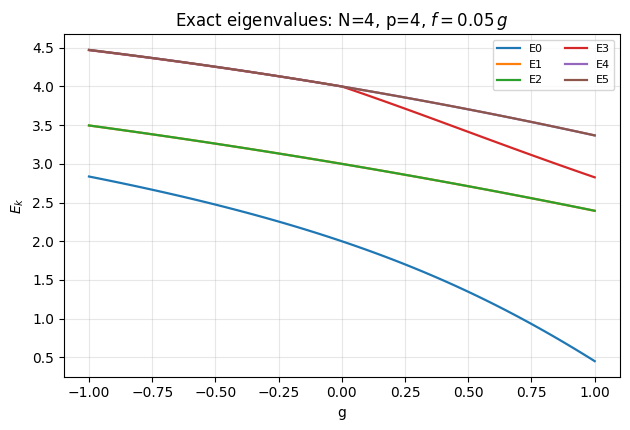

In [8]:
def eigenvalue_sweep(n_levels, n_part, alpha, k=6, gmin=-1.0, gmax=1.0, ng=121, sz2=0):
    gs = np.linspace(gmin, gmax, ng)
    data = np.array([lowest_eigenvalues(n_levels, n_part, g, alpha * g, k=k, sz2=sz2)
                     for g in gs])
    return gs, data

def plot_sweep(n_levels, n_part, alpha, k=6, **kw):
    gs, data = eigenvalue_sweep(n_levels, n_part, alpha, k=k, **kw)
    fig, ax = plt.subplots(figsize=(6.4, 4.4))
    for m in range(data.shape[1]):
        ax.plot(gs, data[:, m], lw=1.6, label=f"E{m}")
    ax.set_xlabel("g"); ax.set_ylabel(r"$E_k$")
    ax.set_title(rf"Exact eigenvalues: N={n_part}, p={n_levels}, $f={alpha}\,g$")
    ax.grid(alpha=0.3); ax.legend(ncol=2, fontsize=8, loc="best")
    fig.tight_layout()
    return fig

fig = plot_sweep(L, N, alpha=0.05, k=6)

Try the strong particle–hole regime, where — as the paper discusses — the low-lying
structure becomes more intricate (level crossings / intruder-state behaviour):

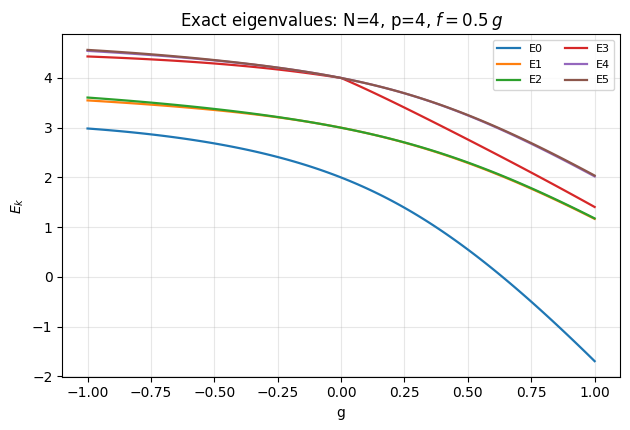

In [9]:
fig = plot_sweep(L, N, alpha=0.5, k=6)

## 8. Scaling and extensions

* **Larger systems.** The full dimension is $\binom{2L}{N}$; restricting to the balanced
  $S_z$ sector (the default `sz2=0`) already cuts this substantially, and the Lanczos solver
  only needs the few lowest states. Because the matrix is stored sparsely, moderately large
  $L$ and $N$ are reachable on a laptop.
* **Pure pairing.** Set `f=0` to recover the exactly-solvable pairing (Richardson) limit used
  in Sec. 2.3 of the paper.
* **Performance kernels.** For production-scale runs the Python operator-application loop in
  `build_hamiltonian` is the natural candidate to move into a compiled kernel
  (object-oriented C++ or Fortran), keeping this notebook as the orchestration and
  visualization layer. The bitstring representation and the sign convention carry over
  unchanged.

You can wrap the whole thing in a small experiment, e.g. compare `sz2=0` against `sz2=None`
(full space) to see the spin-multiplet degeneracies appear, or push `N`, `L` upward and time
the Lanczos solve.